## ANALISIS EXPLORATORIO DE DATOS

#### Inspeccionar dataset (archivo CSV)

#### Importamos librerias

In [4]:
!pip install -r requirements.txt

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings
import re
from utils.plot_functions import *
 
warnings.filterwarnings("ignore")

#### Inspeccionamos el dataset

In [6]:
df = pd.read_csv(r'C:\Users\Demian\Documents\Proyectos\Generador de descripciones\dataset\Reviews.csv')

In [7]:
df.shape

(568454, 10)

In [8]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [10]:
df['ProfileName'] = df['ProfileName'].fillna('UNKNOWN_USER')
df['Summary'] = df['Summary'].fillna('NO SUMMARY')

In [11]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [12]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [13]:
df["Time"] = pd.to_datetime(df["Time"], unit="s")

In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Id                      568454 non-null  int64         
 1   ProductId               568454 non-null  object        
 2   UserId                  568454 non-null  object        
 3   ProfileName             568454 non-null  object        
 4   HelpfulnessNumerator    568454 non-null  int64         
 5   HelpfulnessDenominator  568454 non-null  int64         
 6   Score                   568454 non-null  int64         
 7   Time                    568454 non-null  datetime64[ns]
 8   Summary                 568454 non-null  object        
 9   Text                    568454 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 43.4+ MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,568454
mean,284227.500000,1.743817,2.22881,4.183199,2011-01-28 23:16:44.902419712
min,1.000000,0.000000,0.00000,1.000000,1999-10-08 00:00:00
25%,142114.250000,0.000000,0.00000,4.000000,2010-04-15 00:00:00
50%,284227.500000,0.000000,1.00000,5.000000,2011-07-20 00:00:00
75%,426340.750000,2.000000,2.00000,5.000000,2012-03-26 00:00:00
max,568454.000000,866.000000,923.00000,5.000000,2012-10-26 00:00:00
std,164098.679298,7.636513,8.28974,1.310436,NaN


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.duplicated(
    subset=["ProductId","UserId","Text"]
).sum()

np.int64(1309)

In [17]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

## Creamos Variables Auxiliares para los gráficos

In [18]:
df["review_length"] = (
    df["Text"]
      .str.split()
      .str.len()
)

In [19]:
df["summary_length"] = (
    df["Summary"]
      .str.split()
      .str.len()
)

In [20]:
df["helpfulness_ratio"] = (
    df["HelpfulnessNumerator"] /
    df["HelpfulnessDenominator"].replace(0,np.nan)
)

df["helpfulness_ratio"] = (
    df["helpfulness_ratio"]
    .fillna(0)
)

## EDA

## Distribuciones Univariadas

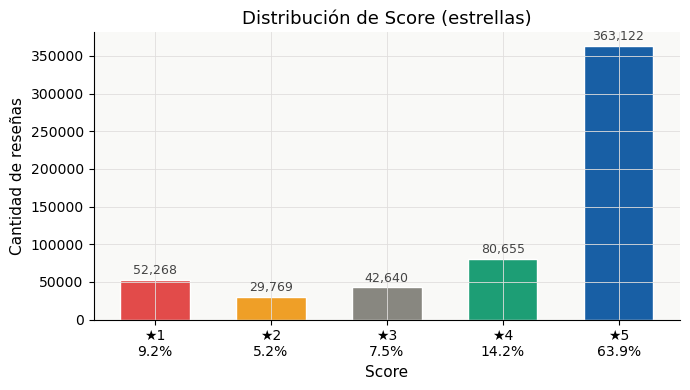

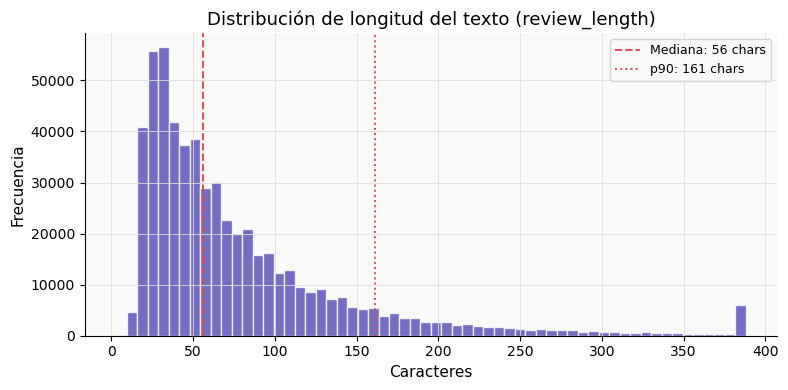

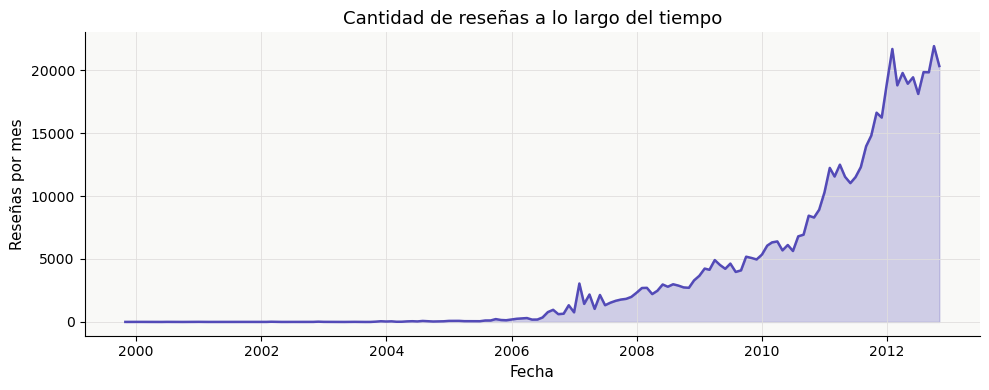

In [21]:
df_score = plot_score_distribution(df)
df_longitud_texto = plot_text_length_distribution(df)
df_grafico_3 = plot_reviews_over_time(df)

## Variables Categóricas

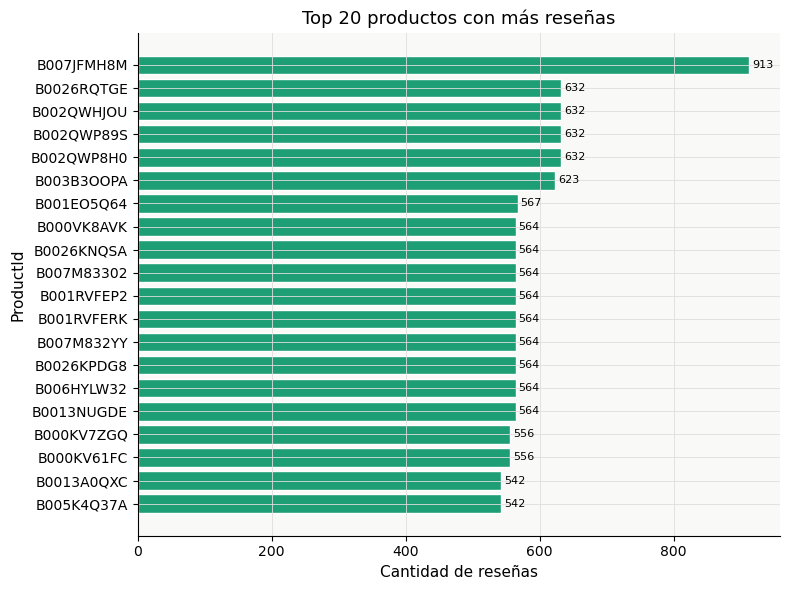

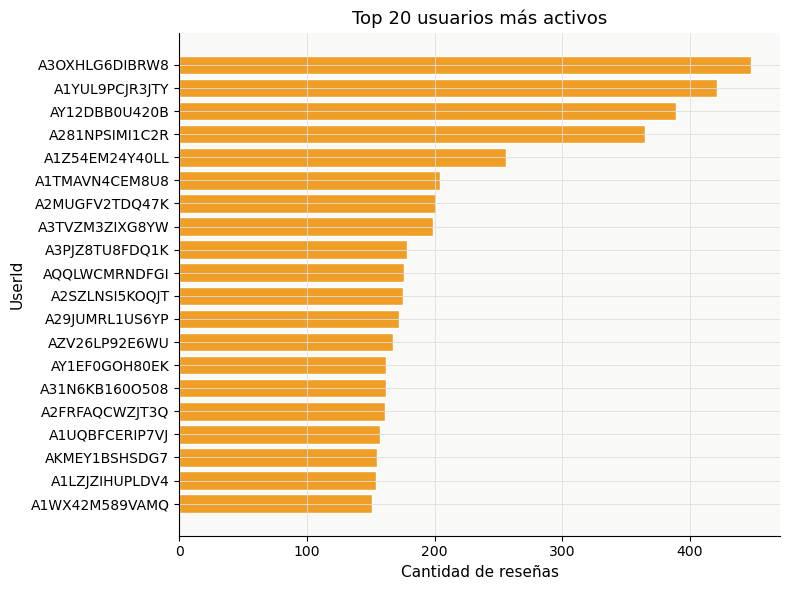

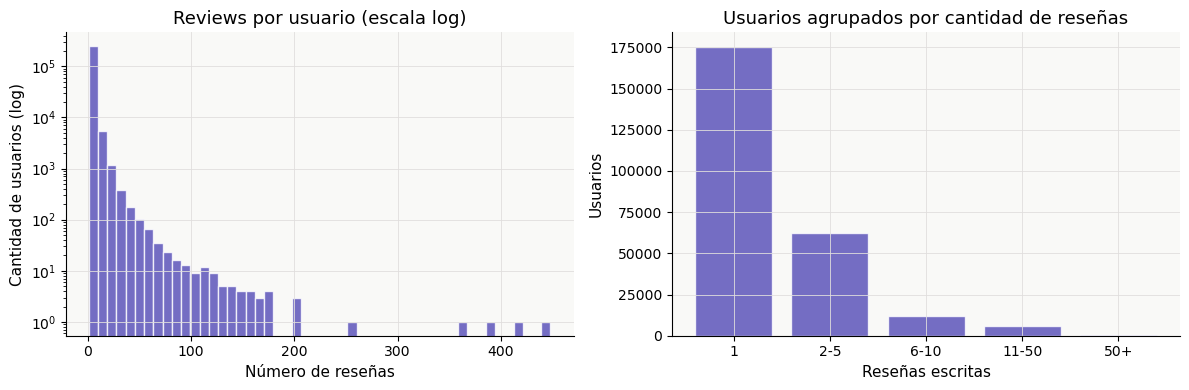

In [22]:
df_graf = plot_top_products(df)
df_graf_2 = plot_top_users(df)
df_graf_3 = plot_reviews_per_user_distribution(df)

## Helpfulness

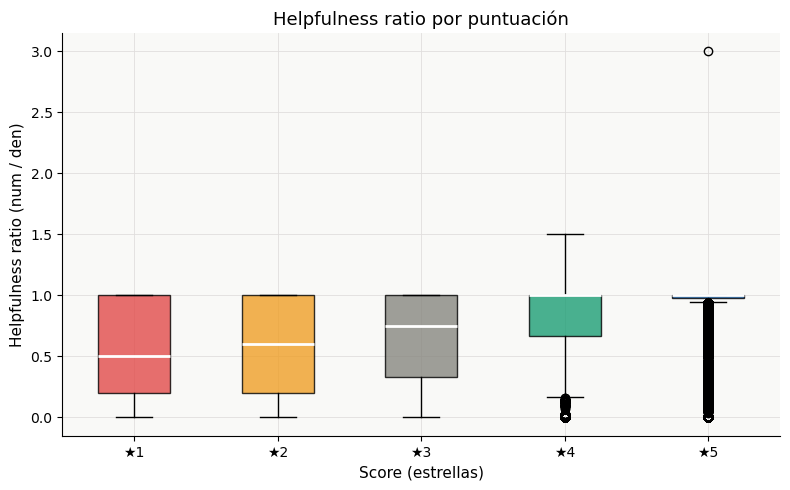

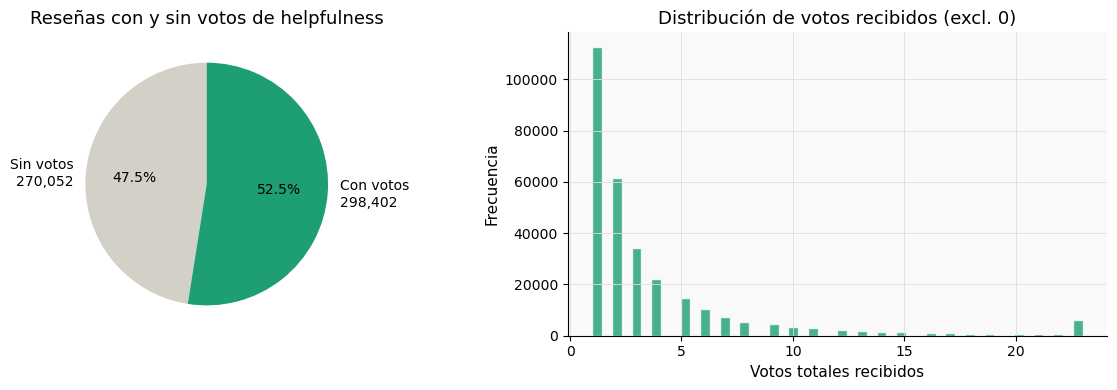

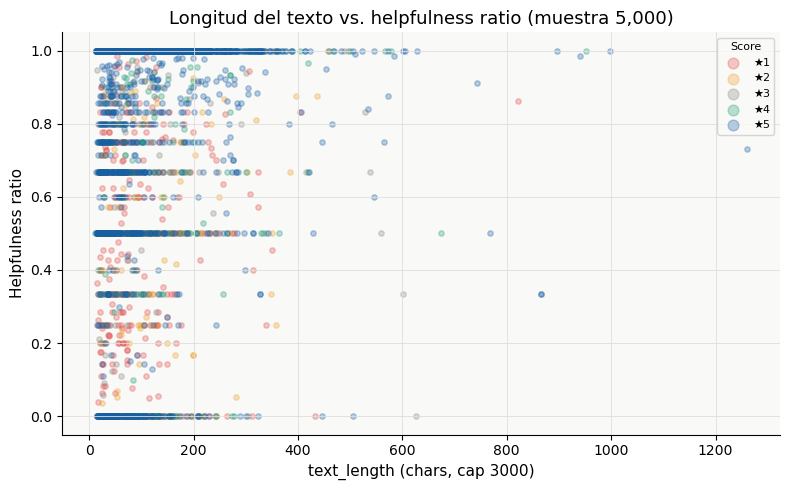

In [23]:
graficos_text = plot_helpfulness_ratio_by_score(df)
graficos_text_1 = plot_denominator_distribution(df)
graficos_text_2 = plot_text_length_vs_helpfulness(df)

<Axes: xlabel='Score', ylabel='count'>

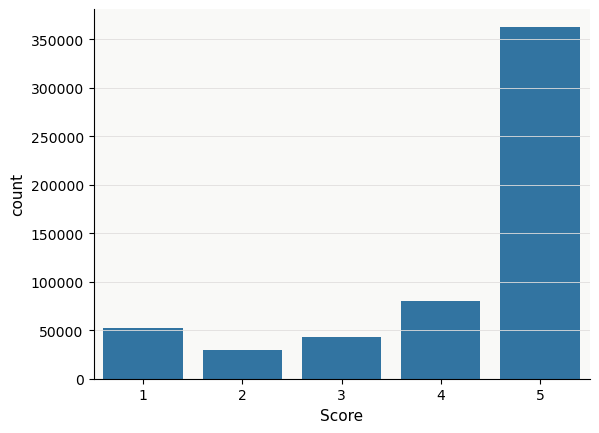

In [24]:
sns.countplot(data=df,x="Score")

<Axes: xlabel='review_length', ylabel='Count'>

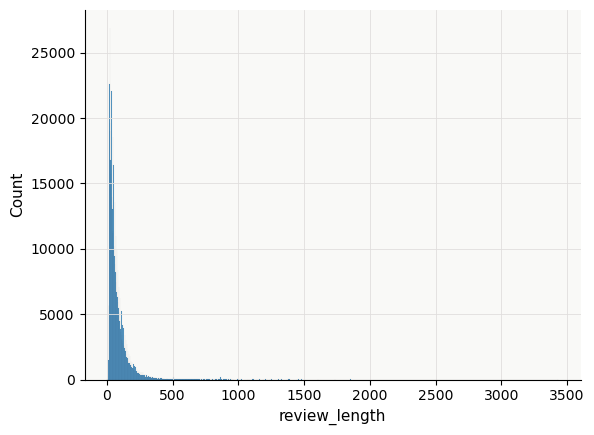

In [25]:
sns.histplot(df["review_length"])

<Axes: xlabel='Score', ylabel='review_length'>

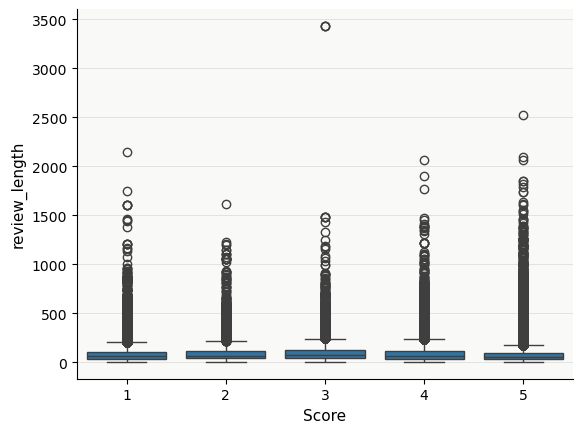

In [26]:
sns.boxplot(
    data=df,
    x="Score",
    y="review_length"
)

<Axes: xlabel='helpfulness_ratio', ylabel='Count'>

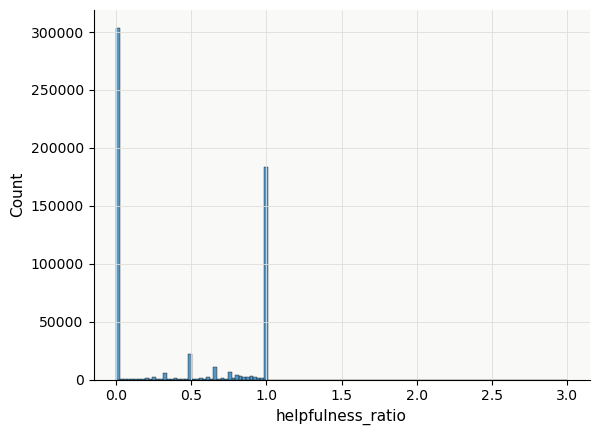

In [27]:
sns.histplot(df["helpfulness_ratio"])

# Inicio del proceso de chunking

En este caso, optamos por utilizar una técnica de Recursive Character Text Splitter. La intención es lograr que cada fragmento mantenga su contexto y la información que busca reflejar originalmente. Al priorizar los saltos de línea o la separación por signos de puntuación, y no separar en N palabras fijas, se espera lograr mantener la información positiva o negativa de las reseñas y así encontrarlas fácilmente al realizar las búsquedas semánticas.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Generamos fragmentos de texto para cada reseña, con un tamaño máximo de 600 caracteres y un solapamiento de 100 caracteres entre fragmentos para mantener el contexto.

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_para_la_bd = []

# Ahora iteramos sobre cada reseña para generar los fragmentos correspondientes
for i, fila in df.iterrows():
    # primero recuperamos el texto de la reseña
    texto_reseña = fila["Text"]
    
    # ahora cortamos el texto de la reseña actual
    
    fragmentos = text_splitter.split_text(texto_reseña)
    
    # procedemos a guardar cada fragmento generado de forma que quede asociado a la información de su producto y el usuario que realizó la reseña
    for i, fragmento in enumerate(fragmentos):
        chunks_para_la_bd.append({
            "chunk_id" : f"{fila['Id']}_c{i}",
            "product_id": fila["ProductId"],
            "user_id": fila["UserId"],
            "score": fila["Score"],
            "helpfulness_ratio": fila["helpfulness_ratio"],
            "chunk_text": fragmento
        })

KeyboardInterrupt: 